# TS-SatFire -- Active Fire Detection -- HybridAFNet v1 -- Inference

This notebook loads the best checkpoint from training (`af_hybrid_v1_best.pt`) and evaluates it on the 12 named AF test fires.

**Outputs produced:**
- Per-fire and aggregate test-set metrics (F1, IoU, Precision, Recall, mF1)
- Threshold sweep on test set
- 9-panel qualitative visualisation with paper-style TP/FP/FN colour masks overlaid on Band I4 (MIR)
- Per-fire breakdown table
- All results saved to `/kaggle/working/`

**Weights and norm stats must be present as a Kaggle dataset input.**  
Set `WEIGHTS_DIR` below to the mount path of that dataset.

In [3]:
import os
import sys
import glob
import json
import math
import random
import warnings
import time
import zipfile
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from tqdm.auto import tqdm

import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f'  GPU {i}  : {props.name}  ({props.total_memory/1024**3:.1f} GB)')

PyTorch  : 2.9.0+cu126
CUDA     : True
  GPU 0  : Tesla T4  (14.6 GB)
  GPU 1  : Tesla T4  (14.6 GB)


## Configuration

Set `WEIGHTS_DIR` to the Kaggle dataset mount path that contains:
- `af_hybrid_v1_best.pt`
- `norm_stats_af_v1.npz`
- `run_meta_af_v1.json`

In [4]:
# ---- Paths ------------------------------------------------------------------
DATA_ROOT  = '/kaggle/input/datasets/z789456sx/ts-satfire/ts-satfire'
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Auto-detect weights: search all /kaggle/input subdirs for the checkpoint file
CKPT_NAME  = 'af_hybrid_v1_best.pt'
STATS_NAME = 'norm_stats_af_v1.npz'
META_NAME  = 'run_meta_af_v1.json'

def _find_file(name):
    """Search every subdirectory under /kaggle/input for a file by name."""
    for root, dirs, files in os.walk('/kaggle/input'):
        if name in files:
            return os.path.join(root, name)
    return None

CKPT_PATH  = _find_file(CKPT_NAME)
STATS_PATH = _find_file(STATS_NAME)
META_PATH  = _find_file(META_NAME)

# Fallback: also check /kaggle/working (if weights were produced in same session)
for name, attr in [(CKPT_NAME, 'CKPT_PATH'), (STATS_NAME, 'STATS_PATH')]:
    if locals()[attr] is None:
        p = os.path.join('/kaggle/working', name)
        if os.path.exists(p):
            locals()[attr] = p

# ---- Dataset hyperparameters (must match training exactly) ------------------
SEED            = 42
TIME_STEPS      = 6
CHANS_PER_STEP  = 8
PATCH_SIZE      = None   # None = use full image at inference (no cropping)
VAL_FRACTION    = 0.20
MIN_FIRE_PIXELS = 10
MAX_NEG_RATIO   = 2
TEST_INTERVAL   = TIME_STEPS  # non-overlapping windows at test time

# ---- Model hyperparameters (must match training exactly) --------------------
BASE_CH         = 48
N_HEADS         = 4
N_TRANS_LAYERS  = 4
TRANS_FF_DIM    = 512
TRANS_DROPOUT   = 0.1

# ---- Inference --------------------------------------------------------------
INFER_THRESHOLD = 0.75   # optimal threshold from training PR sweep
BATCH_SIZE      = 4

# ---- Named AF test fires (from paper Fig 3c) --------------------------------
AF_TEST_NAMED = {
    'currowan_fire', 'thomas_fire', 'camp_fire', 'tubbs_fire',
    'creek_fire', 'dixie_fire', 'mosquito_fire', 'lytton_fire',
    'blue_ridge_fire', 'double_creek_fire', 'eagle_bluff_fire',
    'calfcanyon_fire', 'carr_fire',
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'Device         : {device}')
print(f'TIME_STEPS     : {TIME_STEPS}')
print(f'Threshold      : {INFER_THRESHOLD}')
print()

# Report what was found
print('Searching for weight files under /kaggle/input and /kaggle/working ...')
for label, path in [('Checkpoint ', CKPT_PATH), ('Norm stats ', STATS_PATH), ('Meta      ', META_PATH)]:
    if path and os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024**2
        print(f'  FOUND  {label}: {path}  ({size_mb:.1f} MB)')
    else:
        print(f'  MISSING {label}: {label.strip()} not found')

if CKPT_PATH is None or not os.path.exists(CKPT_PATH):
    print()
    print('ERROR: Checkpoint not found.')
    print('Steps to fix:')
    print('  1. Go to the training notebook output')
    print('  2. Click "Save Version" then "Data" tab')
    print('  3. Add the output as a dataset to this notebook via "+ Add Data"')
    print('  4. The file af_hybrid_v1_best.pt will then be auto-detected.')
    raise FileNotFoundError(f'{CKPT_NAME} not found under /kaggle/input')

if STATS_PATH is None or not os.path.exists(STATS_PATH):
    raise FileNotFoundError(f'{STATS_NAME} not found under /kaggle/input')

print()
print(f'Checkpoint : {CKPT_PATH}')
print(f'Norm stats : {STATS_PATH}')


Device         : cuda
TIME_STEPS     : 6
Threshold      : 0.75

Searching for weight files under /kaggle/input and /kaggle/working ...
  FOUND  Checkpoint : /kaggle/input/datasets/con1los/af-hybrid-v1-weights/af_hybrid_v1_best.pt  (32.6 MB)
  FOUND  Norm stats : /kaggle/input/datasets/con1los/af-hybrid-v1-weights/norm_stats_af_v1.npz  (0.0 MB)
  FOUND  Meta      : /kaggle/input/datasets/con1los/af-hybrid-v1-weights/run_meta_af_v1.json  (0.0 MB)

Checkpoint : /kaggle/input/datasets/con1los/af-hybrid-v1-weights/af_hybrid_v1_best.pt
Norm stats : /kaggle/input/datasets/con1los/af-hybrid-v1-weights/norm_stats_af_v1.npz


## Dataset discovery and test-fire identification

In [5]:
if not os.path.isdir(DATA_ROOT):
    raise RuntimeError(f'Dataset not found at {DATA_ROOT}')

all_dirs = sorted([
    d for d in glob.glob(os.path.join(DATA_ROOT, '*'))
    if os.path.isdir(d)
])
REQUIRED = {'VIIRS_Day', 'VIIRS_Night'}
fire_dirs = [
    d for d in all_dirs
    if REQUIRED.issubset(set(os.listdir(d)))
    and len(glob.glob(os.path.join(d, 'VIIRS_Day', '*.tif'))) >= TIME_STEPS
]

def is_af_test(fd):
    return os.path.basename(fd) in AF_TEST_NAMED

test_fires = [fd for fd in fire_dirs if is_af_test(fd)]
train_pool = [fd for fd in fire_dirs if not is_af_test(fd)]
rng = random.Random(SEED)
rng.shuffle(train_pool)
n_val      = max(1, int(len(train_pool) * VAL_FRACTION))
val_fires  = train_pool[:n_val]

print(f'Total valid fires : {len(fire_dirs)}')
print(f'Test fires found  : {len(test_fires)}')
print()
for fd in test_fires:
    n_days = len(glob.glob(os.path.join(fd, 'VIIRS_Day', '*.tif')))
    print(f'  {os.path.basename(fd):<30}  {n_days} days')

if len(test_fires) < 5:
    print('\nWARNING: fewer than 5 AF test fires found.')
    print('Falling back to validation set for qualitative visualisation.')

Total valid fires : 172
Test fires found  : 12

  blue_ridge_fire                 10 days
  calfcanyon_fire                 10 days
  camp_fire                       10 days
  carr_fire                       10 days
  creek_fire                      10 days
  dixie_fire                      10 days
  double_creek_fire               10 days
  eagle_bluff_fire                10 days
  lytton_fire                     10 days
  mosquito_fire                   10 days
  thomas_fire                     10 days
  tubbs_fire                      10 days


## Data loading utilities

Exact copies from the training notebook -- must not be modified.

In [6]:
CHAN_NAMES = ['I1 (Red)', 'I2 (NIR)', 'I3 (SWIR)', 'I4 (MIR day)',
              'I5 (LWIR day)', 'M11 (SWIR2)', 'I4 Night', 'I5 Night']

def get_af_label_from_day(day_path):
    """Band 7 of VIIRS Day GeoTIFF is the VNP14IMG fire mask. Values >= 7 = fire."""
    try:
        with rasterio.open(day_path) as src:
            if src.count >= 7:
                mask = src.read(7).astype(np.float32)
                return (mask >= 7).astype(np.float32)
    except Exception:
        pass
    return None


def load_frame_af(fd, day_path, return_label=False):
    """Load 8-channel frame: 6 spectral day + 2 night. Optionally returns AF label."""
    date_str   = os.path.basename(day_path).replace('_VIIRS_Day.tif', '')
    night_path = os.path.join(fd, 'VIIRS_Night', f'{date_str}_VIIRS_Night.tif')
    with rasterio.open(day_path) as src:
        day_arr = src.read().astype(np.float32)
    spectral = day_arr[:6]
    H, W = spectral.shape[1], spectral.shape[2]
    if os.path.exists(night_path):
        with rasterio.open(night_path) as src:
            night = src.read().astype(np.float32)[:2, :H, :W]
    else:
        night = np.full((2, H, W), np.nan, np.float32)
    frame = np.concatenate([spectral, night], axis=0)  # (8, H, W)
    if return_label:
        label = (day_arr[6] >= 7).astype(np.float32) if day_arr.shape[0] >= 7 \
                else np.zeros((H, W), np.float32)
        return frame, label
    return frame


# Load normalisation statistics
stats = np.load(STATS_PATH)
CHAN_MEANS = stats['means']
CHAN_STDS  = stats['stds']
CLIP_LO    = stats['clip_lo']
CLIP_HI    = stats['clip_hi']

print(f'Loaded norm stats from {STATS_PATH}')
print(f'{"Chan":<5} {"Name":<18} {"Mean":>10} {"Std":>10}')
print('-' * 48)
for c in range(CHANS_PER_STEP):
    print(f'{c:<5} {CHAN_NAMES[c]:<18} {CHAN_MEANS[c]:>10.3f} {CHAN_STDS[c]:>10.3f}')

print('Data utilities ready.')

Loaded norm stats from /kaggle/input/datasets/con1los/af-hybrid-v1-weights/norm_stats_af_v1.npz
Chan  Name                     Mean        Std
------------------------------------------------
0     I1 (Red)               17.146     14.468
1     I2 (NIR)               25.592     14.209
2     I3 (SWIR)              21.276     10.634
3     I4 (MIR day)          309.870     13.301
4     I5 (LWIR day)         298.432     17.684
5     M11 (SWIR2)            15.205      9.215
6     I4 Night              281.805     10.782
7     I5 Night              280.759     12.221
Data utilities ready.


## Model definition

Exact copy from training notebook.

In [7]:
class DoubleConv2D(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class TemporalTransformer(nn.Module):
    def __init__(self, d_model, n_heads, n_layers, ff_dim, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=n_layers, norm=nn.LayerNorm(d_model)
        )
        self.pos_embed = nn.Parameter(torch.zeros(1, TIME_STEPS, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        x = x + self.pos_embed[:, :x.shape[1], :]
        return self.transformer(x)


class HybridAFNet(nn.Module):
    def __init__(self, in_ch=CHANS_PER_STEP, base_ch=BASE_CH,
                 n_heads=N_HEADS, n_layers=N_TRANS_LAYERS,
                 ff_dim=TRANS_FF_DIM, dropout=TRANS_DROPOUT, n_classes=2):
        super().__init__()
        b = base_ch
        self.enc1 = DoubleConv2D(in_ch, b,    dropout=0.0)
        self.enc2 = DoubleConv2D(b,    b*2,   dropout=0.0)
        self.enc3 = DoubleConv2D(b*2,  b*4,   dropout=0.1)
        self.enc4 = DoubleConv2D(b*4,  b*8,   dropout=0.1)
        self.pool = nn.MaxPool2d(2, 2)
        d_model   = b * 8
        self.temporal = TemporalTransformer(
            d_model=d_model, n_heads=n_heads,
            n_layers=n_layers, ff_dim=ff_dim, dropout=dropout
        )
        self.proj = nn.Sequential(nn.Linear(d_model, d_model), nn.ReLU(inplace=True))
        self.up4  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec4 = DoubleConv2D(b*8 + b*4, b*4, dropout=0.1)
        self.up3  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec3 = DoubleConv2D(b*4 + b*2, b*2, dropout=0.1)
        self.up2  = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec2 = DoubleConv2D(b*2 + b,   b,   dropout=0.0)
        self.dec1 = DoubleConv2D(b,          b,   dropout=0.0)
        self.head = nn.Conv2d(b, n_classes, 1)

    def forward(self, x):
        N, C, T, H, W = x.shape
        x_flat  = x.permute(0, 2, 1, 3, 4).reshape(N * T, C, H, W)
        e1_flat = self.enc1(x_flat)
        e2_flat = self.enc2(self.pool(e1_flat))
        e3_flat = self.enc3(self.pool(e2_flat))
        e4_flat = self.enc4(self.pool(e3_flat))
        last_idx = torch.arange(T - 1, N * T, T, device=x.device)
        e1_last, e2_last = e1_flat[last_idx], e2_flat[last_idx]
        e3_last, e4_last = e3_flat[last_idx], e4_flat[last_idx]
        seq     = e4_flat.mean(dim=[2, 3]).reshape(N, T, -1)
        seq_out = self.temporal(seq)
        ctx     = self.proj(seq_out[:, -1, :])
        fused   = e4_last + ctx.unsqueeze(-1).unsqueeze(-1).expand_as(e4_last)
        d4 = self.dec4(torch.cat([self.up4(fused), e3_last], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4),    e2_last], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3),    e1_last], dim=1))
        return self.head(self.dec1(d2))


def pad_to_multiple(x, multiple=16):
    H, W = x.shape[-2], x.shape[-1]
    pH = (multiple - H % multiple) % multiple
    pW = (multiple - W % multiple) % multiple
    if pH > 0 or pW > 0:
        x = F.pad(x, (0, pW, 0, pH))
    return x, H, W


print('Model classes defined.')

Model classes defined.


## Load checkpoint

In [8]:
model = HybridAFNet(
    in_ch=CHANS_PER_STEP, base_ch=BASE_CH,
    n_heads=N_HEADS, n_layers=N_TRANS_LAYERS,
    ff_dim=TRANS_FF_DIM, dropout=TRANS_DROPOUT
).to(device)

state = torch.load(CKPT_PATH, map_location=device)
# Handle DataParallel prefix
if any(k.startswith('module.') for k in state.keys()):
    state = {k.replace('module.', ''): v for k, v in state.items()}
model.load_state_dict(state)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'Checkpoint loaded : {CKPT_PATH}')
print(f'Parameters        : {n_params:,}  ({n_params/1e6:.2f}M)')
print(f'Model set to eval mode.')

Checkpoint loaded : /kaggle/input/datasets/con1los/af-hybrid-v1-weights/af_hybrid_v1_best.pt
Parameters        : 8,523,682  (8.52M)
Model set to eval mode.


## Metrics class

In [9]:
class FireMetrics:
    def __init__(self):
        self.tp = self.fp = self.fn = 0
        self.sample_f1s = []

    def update(self, logits, targets, threshold=INFER_THRESHOLD):
        probs = torch.softmax(logits.float(), dim=1)[:, 1]
        preds = (probs > threshold).long()
        tgt   = targets.long()
        self.tp += int((preds * tgt).sum())
        self.fp += int((preds * (1 - tgt)).sum())
        self.fn += int(((1 - preds) * tgt).sum())
        for i in range(preds.shape[0]):
            tp_i = int((preds[i] * tgt[i]).sum())
            fp_i = int((preds[i] * (1 - tgt[i])).sum())
            fn_i = int(((1 - preds[i]) * tgt[i]).sum())
            d = 2*tp_i + fp_i + fn_i
            self.sample_f1s.append(2*tp_i / d if d > 0 else 0.0)

    @property
    def F1(self):
        d = 2*self.tp + self.fp + self.fn
        return 2*self.tp / d if d > 0 else 0.0

    @property
    def IoU(self):
        d = self.tp + self.fp + self.fn
        return self.tp / d if d > 0 else 0.0

    @property
    def mF1(self):
        return float(np.mean(self.sample_f1s)) if self.sample_f1s else 0.0

    @property
    def precision(self):
        d = self.tp + self.fp
        return self.tp / d if d > 0 else 0.0

    @property
    def recall(self):
        d = self.tp + self.fn
        return self.tp / d if d > 0 else 0.0

print('FireMetrics defined.')

FireMetrics defined.


## Inference engine

Runs the model over the full image (no cropping) using sliding windows of length T.
The full-resolution prediction map is assembled and compared against the GT label.

In [10]:
def normalise_stack(stack):
    """Apply clip + z-score normalisation to a (T, C, H, W) numpy array."""
    stack = np.clip(stack,
                    CLIP_LO[None, :, None, None],
                    CLIP_HI[None, :, None, None])
    stack = (stack - CHAN_MEANS[None, :, None, None]) / CHAN_STDS[None, :, None, None]
    stack = np.nan_to_num(stack, nan=0.0, posinf=0.0, neginf=0.0)
    return stack


@torch.no_grad()
def run_fire_inference(fire_dir, threshold=INFER_THRESHOLD, T=TIME_STEPS):
    """
    Run inference over all sliding windows of a single fire.

    Returns a list of dicts, one per window:
      {
        'day_idx'  : index of the last day in the window,
        'date'     : filename stem of the last day,
        'prob_map' : (H, W) float32 -- fire probability,
        'pred_mask': (H, W) bool    -- thresholded prediction,
        'gt_mask'  : (H, W) bool    -- ground truth AF label,
        'i4_img'   : (H, W) float32 -- Band I4 (MIR) for visualisation,
        'tp'       : int,
        'fp'       : int,
        'fn'       : int,
        'f1'       : float,
        'iou'      : float,
        'precision': float,
        'recall'   : float,
      }
    """
    day_files = sorted(glob.glob(os.path.join(fire_dir, 'VIIRS_Day', '*.tif')))
    if len(day_files) < T:
        return []

    results = []
    for start in range(0, len(day_files) - T + 1, T):  # non-overlapping
        win = day_files[start : start + T]

        # Load frames
        frames, H, W = [], None, None
        for t, dp in enumerate(win):
            is_last = (t == T - 1)
            if is_last:
                frame, gt_label = load_frame_af(fire_dir, dp, return_label=True)
            else:
                frame = load_frame_af(fire_dir, dp)
            if H is None:
                H, W = frame.shape[1], frame.shape[2]
            frames.append(frame[:, :H, :W])
        gt_label = gt_label[:H, :W]

        # Keep raw I4 (band index 3) for background visualisation before normalisation
        i4_raw = frames[-1][3].copy()  # (H, W)

        # Normalise
        stack = normalise_stack(np.stack(frames, axis=0))  # (T, 8, H, W)

        # Tensor: (1, C, T, H, W)
        x = torch.from_numpy(
            stack.transpose(1, 0, 2, 3)[np.newaxis]
        ).float().to(device)

        # Pad to multiple of 16
        x, H_orig, W_orig = pad_to_multiple(x)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(x)  # (1, 2, H_pad, W_pad)

        prob_map  = torch.softmax(logits, dim=1)[0, 1].cpu().numpy()  # (H_pad, W_pad)
        prob_map  = prob_map[:H_orig, :W_orig]                        # crop padding
        pred_mask = (prob_map > threshold).astype(bool)
        gt_bool   = gt_label.astype(bool)

        tp = int((pred_mask & gt_bool).sum())
        fp = int((pred_mask & ~gt_bool).sum())
        fn = int((~pred_mask & gt_bool).sum())
        f1        = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0.0
        iou       = tp / (tp + fp + fn)     if (tp + fp + fn) > 0     else 0.0
        precision = tp / (tp + fp)          if (tp + fp) > 0          else 0.0
        recall    = tp / (tp + fn)          if (tp + fn) > 0          else 0.0

        results.append({
            'day_idx'  : start + T - 1,
            'date'     : os.path.basename(win[-1]).replace('_VIIRS_Day.tif', ''),
            'prob_map' : prob_map,
            'pred_mask': pred_mask,
            'gt_mask'  : gt_bool,
            'i4_img'   : i4_raw,
            'tp': tp, 'fp': fp, 'fn': fn,
            'f1': f1, 'iou': iou,
            'precision': precision,
            'recall'   : recall,
        })

    return results


print('Inference engine ready.')

Inference engine ready.


## Run inference on all test fires and compute aggregate metrics

In [11]:
# Use test fires if available, otherwise fall back to val fires
eval_fires = test_fires if len(test_fires) >= 3 else val_fires
eval_label = 'test' if eval_fires is test_fires else 'validation'
print(f'Evaluating on {len(eval_fires)} {eval_label} fires  (threshold={INFER_THRESHOLD})')
print()

global_metrics = FireMetrics()
per_fire_rows  = []
all_fire_results = {}   # fire_id -> list of window results

for fd in tqdm(eval_fires, desc='Inference'):
    fid     = os.path.basename(fd)
    windows = run_fire_inference(fd, threshold=INFER_THRESHOLD)
    if not windows:
        continue
    all_fire_results[fid] = windows

    # Accumulate global TP/FP/FN
    agg_tp = sum(w['tp'] for w in windows)
    agg_fp = sum(w['fp'] for w in windows)
    agg_fn = sum(w['fn'] for w in windows)
    f1_fire  = 2*agg_tp / (2*agg_tp + agg_fp + agg_fn) if (2*agg_tp+agg_fp+agg_fn) > 0 else 0.0
    iou_fire = agg_tp / (agg_tp + agg_fp + agg_fn)     if (agg_tp+agg_fp+agg_fn) > 0     else 0.0
    pre_fire = agg_tp / (agg_tp + agg_fp)              if (agg_tp+agg_fp) > 0              else 0.0
    rec_fire = agg_tp / (agg_tp + agg_fn)              if (agg_tp+agg_fn) > 0              else 0.0

    global_metrics.tp += agg_tp
    global_metrics.fp += agg_fp
    global_metrics.fn += agg_fn
    global_metrics.sample_f1s.extend([w['f1'] for w in windows])

    per_fire_rows.append({
        'fire_id'   : fid,
        'n_windows' : len(windows),
        'tp'        : agg_tp,
        'fp'        : agg_fp,
        'fn'        : agg_fn,
        'f1'        : f1_fire,
        'iou'       : iou_fire,
        'precision' : pre_fire,
        'recall'    : rec_fire,
    })

df_fires = pd.DataFrame(per_fire_rows).sort_values('f1', ascending=False)

print(f'\nPer-fire results ({eval_label} set):')
print(df_fires.to_string(index=False, float_format='{:.4f}'.format))
print()
print('='*60)
print(f'Aggregate test metrics  (threshold={INFER_THRESHOLD})')
print('='*60)
print(f'  F1        : {global_metrics.F1:.4f}')
print(f'  IoU       : {global_metrics.IoU:.4f}')
print(f'  Precision : {global_metrics.precision:.4f}')
print(f'  Recall    : {global_metrics.recall:.4f}')
print(f'  mF1       : {global_metrics.mF1:.4f}')
print()
print('Paper baselines (AF task, test set F1):')
paper = {'U-Net 2D': 0.731, 'LSTM-3': 0.765, 'T4Fire': 0.802,
         'U-Net-3D': 0.748, 'UNETR-3D': 0.811, 'SwinUNETR-3D': 0.797}
for name, f1 in sorted(paper.items(), key=lambda x: x[1]):
    diff = global_metrics.F1 - f1
    mark = f'+{diff:.3f}' if diff >= 0 else f'{diff:.3f}'
    print(f'  {name:<18}: {f1:.3f}   ours {mark}')
print('='*60)

# Save per-fire table
df_fires.to_csv(os.path.join(OUTPUT_DIR, 'per_fire_metrics.csv'), index=False)
print(f'Saved per_fire_metrics.csv')

Evaluating on 12 test fires  (threshold=0.75)



Inference:   0%|          | 0/12 [00:00<?, ?it/s]


Per-fire results (test set):
          fire_id  n_windows   tp   fp   fn     f1    iou  precision  recall
       dixie_fire          1 1158  360  122 0.8277 0.7061     0.7628  0.9047
       creek_fire          1 1865  377  412 0.8254 0.7027     0.8318  0.8191
      lytton_fire          1 1054  370  298 0.7594 0.6121     0.7402  0.7796
      thomas_fire          1  598  110  271 0.7584 0.6108     0.8446  0.6881
       tubbs_fire          1  441  151  149 0.7462 0.5951     0.7449  0.7475
        camp_fire          1  313   95  167 0.7050 0.5443     0.7672  0.6521
        carr_fire          1 1315  246 1022 0.6747 0.5091     0.8424  0.5627
  blue_ridge_fire          1   14   12   39 0.3544 0.2154     0.5385  0.2642
  calfcanyon_fire          1    0   25    0 0.0000 0.0000     0.0000  0.0000
double_creek_fire          1    0 1644    0 0.0000 0.0000     0.0000  0.0000
 eagle_bluff_fire          1    0    0    0 0.0000 0.0000     0.0000  0.0000
    mosquito_fire          1    0  422    0 0.

## Threshold sweep on test set

Threshold sweep results (test set):
  Threshold       F1   Precision    Recall      IoU
----------------------------------------------------
       0.10   0.6764      0.5538    0.8686   0.5110
       0.15   0.6827      0.5721    0.8465   0.5183
       0.20   0.6852      0.5831    0.8306   0.5211
       0.25   0.6876      0.5923    0.8193   0.5239
       0.30   0.6880      0.5984    0.8093   0.5244
       0.35   0.6892      0.6049    0.8006   0.5257 <-- best
       0.40   0.6885      0.6096    0.7910   0.5250
       0.45   0.6885      0.6140    0.7834   0.5249
       0.50   0.6882      0.6178    0.7766   0.5246
       0.55   0.6874      0.6220    0.7681   0.5237
       0.60   0.6857      0.6252    0.7590   0.5217
       0.65   0.6844      0.6294    0.7498   0.5202
       0.70   0.6848      0.6355    0.7425   0.5207
       0.75   0.6824      0.6394    0.7315   0.5179
       0.80   0.6791      0.6436    0.7189   0.5142
       0.85   0.6755      0.6500    0.7031   0.5100
       0.90   0.67

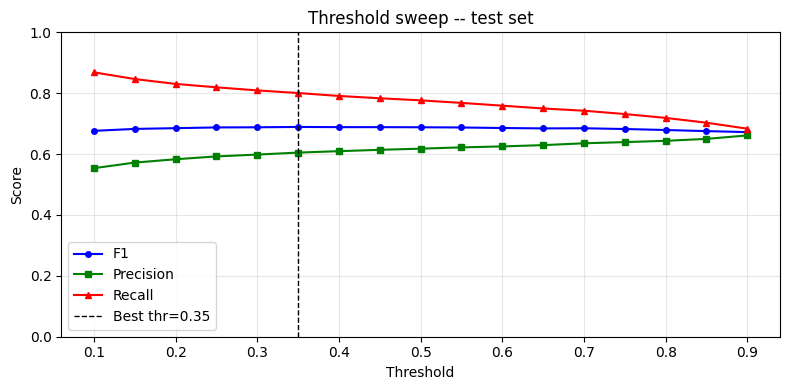

Saved threshold_sweep_test.png


In [12]:
thresholds = np.arange(0.10, 0.95, 0.05)
sweep_rows = []

for thr in thresholds:
    m = FireMetrics()
    for windows in all_fire_results.values():
        for w in windows:
            pred = (w['prob_map'] > thr).astype(bool)
            gt   = w['gt_mask']
            tp = int((pred & gt).sum())
            fp = int((pred & ~gt).sum())
            fn = int((~pred & gt).sum())
            m.tp += tp; m.fp += fp; m.fn += fn
            d = 2*tp + fp + fn
            m.sample_f1s.append(2*tp/d if d > 0 else 0.0)
    sweep_rows.append({
        'threshold': round(float(thr), 2),
        'F1'       : m.F1,
        'Precision': m.precision,
        'Recall'   : m.recall,
        'IoU'      : m.IoU,
    })

df_sweep = pd.DataFrame(sweep_rows)
best_row  = df_sweep.loc[df_sweep['F1'].idxmax()]

print('Threshold sweep results (test set):')
print(f' {"Threshold":>10}  {"F1":>7}  {"Precision":>10}  {"Recall":>8}  {"IoU":>7}')
print('-'*52)
for _, row in df_sweep.iterrows():
    mark = ' <-- best' if row['threshold'] == best_row['threshold'] else ''
    print(f' {row["threshold"]:>10.2f}  {row["F1"]:>7.4f}  '
          f'{row["Precision"]:>10.4f}  {row["Recall"]:>8.4f}  '
          f'{row["IoU"]:>7.4f}{mark}')

print(f'\nBest threshold : {best_row["threshold"]}  (F1={best_row["F1"]:.4f})')

# Plot sweep
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_sweep['threshold'], df_sweep['F1'],        'b-o', ms=4, label='F1')
ax.plot(df_sweep['threshold'], df_sweep['Precision'],  'g-s', ms=4, label='Precision')
ax.plot(df_sweep['threshold'], df_sweep['Recall'],     'r-^', ms=4, label='Recall')
ax.axvline(best_row['threshold'], color='k', ls='--', lw=1, label=f'Best thr={best_row["threshold"]}')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold sweep -- test set')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'threshold_sweep_test.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved threshold_sweep_test.png')

## Qualitative visualisation -- 9 panels, paper-style TP/FP/FN colour masks

Each panel shows:
- Background: Band I4 (MIR, 3.7 um) displayed in greyscale -- this is the band most sensitive to active fire heat
- Red overlay  : True Positives  (model correct, fire detected)
- Green overlay: False Positives (model predicts fire, GT says background)
- Blue overlay : False Negatives (model misses fire, GT says fire)

Colour scheme matches the paper Fig 9 exactly.

Plotting 12 fires in a 3x4 grid


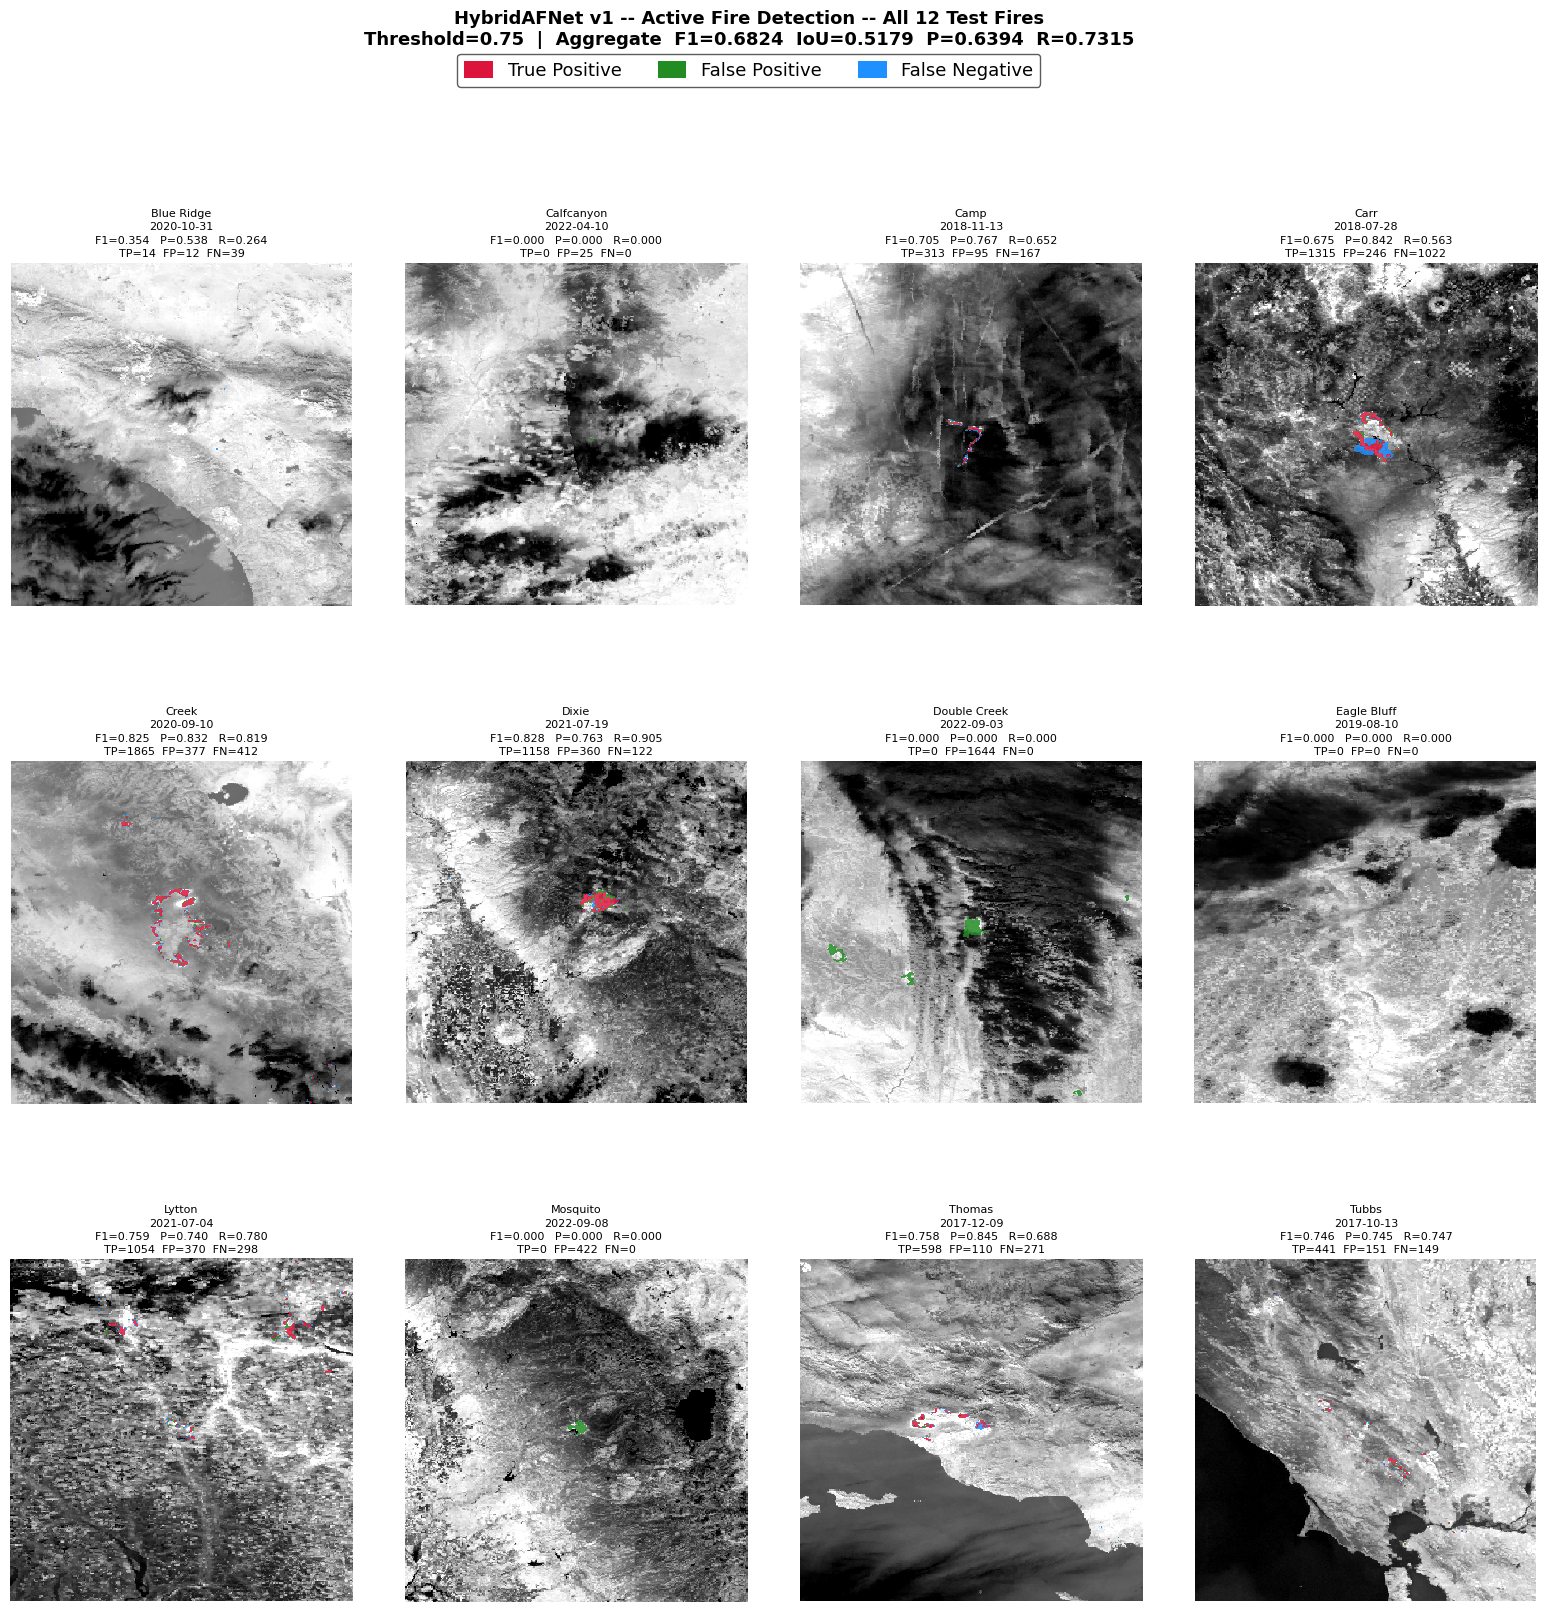

Saved -> /kaggle/working/qual_results_all_fires.png  (12 fires, 3x4 grid)


In [14]:
def make_overlay_rgb(i4_img, pred_mask, gt_mask):
    """
    Compose a paper-style RGB overlay on a greyscale I4 background.
    TP  (pred=1, gt=1) -> Red   (220,  20,  60)
    FP  (pred=1, gt=0) -> Green ( 34, 139,  34)
    FN  (pred=0, gt=1) -> Blue  ( 30, 144, 255)
    """
    lo, hi = np.percentile(i4_img[np.isfinite(i4_img)], [2, 98])
    bg  = np.clip((i4_img - lo) / max(hi - lo, 1e-6), 0, 1)
    rgb = np.stack([bg, bg, bg], axis=-1)

    tp_mask = pred_mask & gt_mask
    fp_mask = pred_mask & ~gt_mask
    fn_mask = ~pred_mask & gt_mask

    alpha = 0.85
    rgb[tp_mask] = (1 - alpha) * rgb[tp_mask] + alpha * np.array([220/255,  20/255,  60/255])
    rgb[fp_mask] = (1 - alpha) * rgb[fp_mask] + alpha * np.array([ 34/255, 139/255,  34/255])
    rgb[fn_mask] = (1 - alpha) * rgb[fn_mask] + alpha * np.array([ 30/255, 144/255, 255/255])
    return np.clip(rgb, 0, 1)


def best_window_per_fire(all_results):
    """
    Return exactly one window per fire -- the most informative one.
    Priority:
      3 pts  GT fire + model predicted fire  (both agree)
      2 pts  GT fire only
      1 pt   model predicted fire only
      tie-break: highest per-window F1
    """
    selected = []
    for fid, windows in all_results.items():
        scored = []
        for w in windows:
            has_gt   = bool(w['gt_mask'].sum() > 0)
            has_pred = bool(w['pred_mask'].sum() > 0)
            score = 3 * int(has_gt and has_pred) + 2 * int(has_gt) + int(has_pred)
            scored.append((score, w['f1'], w))
        scored.sort(key=lambda x: (x[0], x[1]), reverse=True)
        selected.append((fid, scored[0][2]))
    selected.sort(key=lambda x: x[0])
    return selected


# --- One representative window per fire, 4-column grid ---
samples  = best_window_per_fire(all_fire_results)
n_fires  = len(samples)
N_COLS   = 4
N_ROWS   = math.ceil(n_fires / N_COLS)

print(f'Plotting {n_fires} fires in a {N_ROWS}x{N_COLS} grid')

fig = plt.figure(figsize=(N_COLS * 5, N_ROWS * 5.8))
gs  = gridspec.GridSpec(N_ROWS, N_COLS, figure=fig, hspace=0.45, wspace=0.08)

for idx, (fid, w) in enumerate(samples):
    ax  = fig.add_subplot(gs[idx // N_COLS, idx % N_COLS])
    rgb = make_overlay_rgb(w['i4_img'], w['pred_mask'], w['gt_mask'])
    ax.imshow(rgb, interpolation='nearest')

    fire_short = fid.replace('_fire', '').replace('_', ' ').title()
    n_tp = int(w['tp'])
    n_fp = int(w['fp'])
    n_fn = int(w['fn'])
    ax.set_title(
        f'{fire_short}\n'
        f'{w["date"]}\n'
        f'F1={w["f1"]:.3f}   P={w["precision"]:.3f}   R={w["recall"]:.3f}\n'
        f'TP={n_tp}  FP={n_fp}  FN={n_fn}',
        fontsize=8, pad=4, linespacing=1.4
    )
    ax.axis('off')

# Hide any leftover empty axes
for idx in range(n_fires, N_ROWS * N_COLS):
    fig.add_subplot(gs[idx // N_COLS, idx % N_COLS]).axis('off')

# Legend
legend_patches = [
    mpatches.Patch(facecolor=(220/255,  20/255,  60/255), label='True Positive'),
    mpatches.Patch(facecolor=( 34/255, 139/255,  34/255), label='False Positive'),
    mpatches.Patch(facecolor=( 30/255, 144/255, 255/255), label='False Negative'),
]
fig.legend(
    handles=legend_patches,
    loc='upper center',
    ncol=3,
    bbox_to_anchor=(0.5, 1.005),
    fontsize=13,
    frameon=True,
    edgecolor='#333',
    handlelength=1.6,
    handleheight=1.1,
)

fig.suptitle(
    f'HybridAFNet v1 -- Active Fire Detection -- All {n_fires} Test Fires\n'
    f'Threshold={INFER_THRESHOLD}  |  '
    f'Aggregate  F1={global_metrics.F1:.4f}  IoU={global_metrics.IoU:.4f}  '
    f'P={global_metrics.precision:.4f}  R={global_metrics.recall:.4f}',
    y=1.025, fontsize=13, fontweight='bold'
)

out_path = os.path.join(OUTPUT_DIR, 'qual_results_all_fires.png')
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved -> {out_path}  ({n_fires} fires, {N_ROWS}x{N_COLS} grid)')

## Per-fire results summary table

In [15]:
print('Per-fire results summary:')
print(f'{"Fire ID":<30} {"Windows":>8} {"F1":>7} {"IoU":>7} {"Prec":>7} {"Rec":>7}')
print('-' * 72)
for _, row in df_fires.iterrows():
    print(f'{row["fire_id"]:<30} {row["n_windows"]:>8.0f} '
          f'{row["f1"]:>7.4f} {row["iou"]:>7.4f} '
          f'{row["precision"]:>7.4f} {row["recall"]:>7.4f}')
print('-' * 72)
print(f'{"AGGREGATE":<30} {"":>8} '
      f'{global_metrics.F1:>7.4f} {global_metrics.IoU:>7.4f} '
      f'{global_metrics.precision:>7.4f} {global_metrics.recall:>7.4f}')
print()

# Comparison table
print('Comparison with paper baselines (AF test set F1):')
print(f'{"Model":<22} {"F1":>7}  {"IoU":>7}  {"Params":>10}')
print('-' * 52)
baselines = [
    ('U-Net 2D',      0.731, 0.605, '10.6M'),
    ('GRU-3',         0.713, 0.601, '64.3K'),
    ('LSTM-3',        0.765, 0.654, '84.9K'),
    ('T4Fire',        0.802, 0.700, '32.5K'),
    ('U-Net-3D',      0.748, 0.628, '31.7M'),
    ('UNETR-3D',      0.811, 0.706, '34.8M'),
    ('SwinUNETR-3D',  0.797, 0.688, '33.2M'),
]
n_params = sum(p.numel() for p in model.parameters())
for name, f1, iou, params in baselines:
    print(f'{name:<22} {f1:>7.3f}  {iou:>7.3f}  {params:>10}')
print(f'{"HybridAFNet v1 (ours)":<22} '
      f'{global_metrics.F1:>7.3f}  {global_metrics.IoU:>7.3f}  '
      f'{n_params/1e6:>9.2f}M'  )
print('-' * 52)

Per-fire results summary:
Fire ID                         Windows      F1     IoU    Prec     Rec
------------------------------------------------------------------------
dixie_fire                            1  0.8277  0.7061  0.7628  0.9047
creek_fire                            1  0.8254  0.7027  0.8318  0.8191
lytton_fire                           1  0.7594  0.6121  0.7402  0.7796
thomas_fire                           1  0.7584  0.6108  0.8446  0.6881
tubbs_fire                            1  0.7462  0.5951  0.7449  0.7475
camp_fire                             1  0.7050  0.5443  0.7672  0.6521
carr_fire                             1  0.6747  0.5091  0.8424  0.5627
blue_ridge_fire                       1  0.3544  0.2154  0.5385  0.2642
calfcanyon_fire                       1  0.0000  0.0000  0.0000  0.0000
double_creek_fire                     1  0.0000  0.0000  0.0000  0.0000
eagle_bluff_fire                      1  0.0000  0.0000  0.0000  0.0000
mosquito_fire                        

## Save all outputs

In [17]:
# Save aggregate metrics to JSON
results_json = {
    'model'            : 'HybridAFNet_v1',
    'eval_set'         : eval_label,
    'n_fires'          : len(eval_fires),
    'threshold'        : INFER_THRESHOLD,
    'F1'               : round(global_metrics.F1, 6),
    'IoU'              : round(global_metrics.IoU, 6),
    'precision'        : round(global_metrics.precision, 6),
    'recall'           : round(global_metrics.recall, 6),
    'mF1'              : round(global_metrics.mF1, 6),
    'TP'               : global_metrics.tp,
    'FP'               : global_metrics.fp,
    'FN'               : global_metrics.fn,
    'best_threshold'   : float(best_row['threshold']),
    'best_threshold_F1': round(float(best_row['F1']), 6),
}
results_path = os.path.join(OUTPUT_DIR, 'test_results_af_v1.json')
with open(results_path, 'w') as f:
    json.dump(results_json, f, indent=2)

output_files = [
    'test_results_af_v1.json',
    'per_fire_metrics.csv',
    'qual_results_all_fires.png',
    'threshold_sweep_test.png',
]

print('Saved files:')
for fname in output_files:
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) // 1024
        print(f'  {fname:<40}  {size_kb:>5} KB')
    else:
        print(f'  {fname:<40}  NOT FOUND')

# Zip
zip_path = os.path.join(OUTPUT_DIR, 'af_hybrid_v1_inference_outputs.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in output_files:
        fpath = os.path.join(OUTPUT_DIR, fname)
        if os.path.exists(fpath):
            zf.write(fpath, fname)
print(f'\nZipped to: {zip_path}')

print()
print('=' * 55)
print('FINAL TEST RESULT')
print(f'  F1        : {global_metrics.F1:.4f}')
print(f'  IoU       : {global_metrics.IoU:.4f}')
print(f'  Precision : {global_metrics.precision:.4f}')
print(f'  Recall    : {global_metrics.recall:.4f}')
print(f'  mF1       : {global_metrics.mF1:.4f}')
print('=' * 55)

Saved files:
  test_results_af_v1.json                       0 KB
  per_fire_metrics.csv                          0 KB
  qual_results_all_fires.png                 3129 KB
  threshold_sweep_test.png                     44 KB

Zipped to: /kaggle/working/af_hybrid_v1_inference_outputs.zip

FINAL TEST RESULT
  F1        : 0.6824
  IoU       : 0.5179
  Precision : 0.6394
  Recall    : 0.7315
  mF1       : 0.4709
